# Generic Helper Functions

Download STEREO-A PLASTIC CDFs from ISWA, unpack the solar-wind moments into a DataFrame, plot quick diagnostics, and save the selected interval to parquet using the same output layout as `CDASWS Downloader.ipynb`.

In [7]:
import os
import re
import shutil
from html.parser import HTMLParser
from pathlib import Path
from urllib.error import HTTPError
from urllib.parse import urljoin, urlparse
from urllib.request import Request, urlopen, urlretrieve

# os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
# os.environ.setdefault("SUNPY_CONFIGDIR", "/private/tmp/sunpy-config")

import astropy.units as u
import cdflib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sunpy.coordinates import get_horizons_coord


EARTH_RADIUS_KM = 6378.0
ISWA_PLASTIC_BASE_URL = "https://iswa.gsfc.nasa.gov/iswa_data_tree/observation/solar/stereo-A/plastic/"
# If your DNS cannot resolve the canonical host, try one of these alternates:
# ISWA_PLASTIC_BASE_URL = "https://iswa.ccmc.gsfc.nasa.gov/iswa_data_tree/observation/solar/stereo-A/plastic/"
# ISWA_PLASTIC_BASE_URL = "https://iswaa-webservice1.ccmc.gsfc.nasa.gov/iswa_data_tree/observation/solar/stereo-A/plastic/"

FILL_VALUES = [
    -1.0e31,
    -9.999999848243207e30,
    -99999.0,
    -999.9000244140625,
]


def time_label(t):
    return str(pd.Timestamp(t).tz_localize(None)).replace(":", "-")


def shock_label(tShock):
    return time_label(tShock)


def resolve_run_interval(run_mode, tShock, custom_t1, custom_t2, window_hours=12):
    if run_mode == "shock":
        center = pd.to_datetime(tShock, utc=True)
        half_window = pd.Timedelta(hours=window_hours / 2)
        return center - half_window, center + half_window, center
    if run_mode == "custom":
        return pd.to_datetime(custom_t1, utc=True), pd.to_datetime(custom_t2, utc=True), None
    raise ValueError(f"Unsupported RUN_MODE: {run_mode!r}")


def resolve_output_dir(run_mode, tShock, t_start, t_end, base_dir="Data"):
    base_dir = Path(base_dir)
    if run_mode == "shock":
        return base_dir / shock_label(tShock)
    if run_mode == "custom":
        return base_dir / "Custom" / f"{time_label(t_start)}-{time_label(t_end)}"
    raise ValueError(f"Unsupported RUN_MODE: {run_mode!r}")


def save_parquet(merged, sat, tShock=None, base_dir="Data", output_dir=None):
    if output_dir is not None:
        out_dir = Path(output_dir)
    elif "OUTPUT_DIR" in globals():
        out_dir = Path(OUTPUT_DIR)
    else:
        out_dir = Path(base_dir) / shock_label(tShock)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / (sat + ".parquet")
    merged.to_parquet(out_path)
    return out_path


class ISWADirectoryParser(HTMLParser):
    def __init__(self):
        super().__init__()
        self.hrefs = []

    def handle_starttag(self, tag, attrs):
        if tag != "a":
            return
        attrs = dict(attrs)
        if "href" in attrs:
            self.hrefs.append(attrs["href"])


def list_directory_hrefs(url):
    parser = ISWADirectoryParser()
    try:
        with urlopen(url) as response:
            parser.feed(response.read().decode("utf-8", errors="replace"))
    except HTTPError as exc:
        if exc.code == 404:
            print(f"Missing ISWA directory, skipping: {url}")
            return []
        raise
    return parser.hrefs


def iswa_plastic_month_url(day):
    return f"{ISWA_PLASTIC_BASE_URL}{day.year}/{day.month:02d}/"


def latest_iswa_plastic_url(day, hrefs):
    date = day.strftime("%Y%m%d")
    pattern = re.compile(rf"^STA_LB_PLASTIC_{date}_V(\d+)\.cdf$")

    candidates = []
    month_url = iswa_plastic_month_url(day)
    for href in hrefs:
        filename = Path(urlparse(href).path).name
        match = pattern.match(filename)
        if match:
            candidates.append((int(match.group(1)), urljoin(month_url, href)))

    if not candidates:
        print(f"No ISWA PLASTIC CDF found for {date} in {month_url}; skipping")
        return None

    return max(candidates, key=lambda item: item[0])[1]


def list_iswa_plastic_urls(t_start, t_end):
    start_day = t_start.normalize().tz_convert(None)
    end_day = t_end.normalize().tz_convert(None)
    days = pd.date_range(start_day, end_day, freq="D")

    urls = []
    month_hrefs = {}
    for day in days:
        month_url = iswa_plastic_month_url(day)
        if month_url not in month_hrefs:
            month_hrefs[month_url] = list_directory_hrefs(month_url)
        url = latest_iswa_plastic_url(day, month_hrefs[month_url])
        if url is not None:
            urls.append(url)

    return urls


def horizons_time_ranges(t_start, t_end, step, max_rows):
    start = pd.to_datetime(t_start, utc=True)
    stop = pd.to_datetime(t_end, utc=True)
    step_delta = pd.Timedelta(step)
    if step_delta <= pd.Timedelta(0):
        raise ValueError(f"HORIZONS step must be positive: {step!r}")
    if max_rows < 2:
        raise ValueError(f"HORIZONS max_rows must be at least 2: {max_rows!r}")
    if stop < start:
        raise ValueError(f"HORIZONS stop must be after start: {start} > {stop}")

    chunk_duration = step_delta * (max_rows - 1)
    chunk_start = start
    while chunk_start <= stop:
        chunk_stop = min(chunk_start + chunk_duration, stop)
        yield chunk_start, chunk_stop
        chunk_start = chunk_stop + step_delta


def horizons_coord_frame(body, t_start, t_end, step, max_rows):
    frames = []
    for chunk_start, chunk_stop in horizons_time_ranges(t_start, t_end, step, max_rows):
        print(f"Fetching HORIZONS coordinates from {chunk_start} to {chunk_stop}")
        coords = get_horizons_coord(
            body,
            {
                "start": chunk_start,
                "stop": chunk_stop,
                "step": step,
            },
        )
        frames.append(
            pd.DataFrame(
                {
                    "radialDistance": coords.radius.to_value(u.km) / EARTH_RADIUS_KM,
                    "heliographicLatitude": coords.lat.to_value(u.deg),
                    "heliographicLongitude": coords.lon.to_value(u.deg),
                },
                # Python datetime cannot represent leap seconds; let Astropy coerce them first.
                index=pd.to_datetime(
                    coords.obstime.utc.to_datetime(leap_second_strict="silent"), utc=True
                ),
            )
        )

    frame = pd.concat(frames).sort_index()
    frame = frame[~frame.index.duplicated(keep="first")]
    frame.index.name = "Epoch"
    return frame


def remote_content_length(url):
    request = Request(url, method="HEAD")
    try:
        with urlopen(request) as response:
            value = response.headers.get("Content-Length")
    except HTTPError as exc:
        if exc.code == 404:
            print(f"Missing remote CDF, skipping: {url}")
            return "missing"
        raise
    return int(value) if value is not None else None


def validate_download_size(path, expected_size, url):
    if expected_size is not None and path.stat().st_size != expected_size:
        raise ValueError(
            f"Incomplete CDF download for {url}: "
            f"{path.stat().st_size} bytes on disk, expected {expected_size}"
        )


def download_cdfs(urls, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    paths = []
    for url in urls:
        path = out_dir / Path(url).name
        expected_size = remote_content_length(url)
        if expected_size == "missing":
            continue
        if path.exists() and (expected_size is None or path.stat().st_size == expected_size):
            print(f"Using existing {path}")
        else:
            if path.exists():
                print(f"Redownloading incomplete {path}")
            else:
                print(f"Downloading {url}")
            try:
                urlretrieve(url, path)
            except HTTPError as exc:
                if exc.code == 404:
                    print(f"Missing remote CDF, skipping: {url}")
                    continue
                raise
            validate_download_size(path, expected_size, url)
        paths.append(path)

    return paths


def unpack_plastic_cdf(path):
    cdf = cdflib.CDF(path)
    epoch = pd.to_datetime(cdflib.cdfepoch.to_datetime(cdf.varget("Epoch1")), utc=True)
    velocity_rtn = np.asarray(cdf.varget("Velocity_RTN"), dtype=float)
    velocity_hertn = np.asarray(cdf.varget("Velocity_HERTN"), dtype=float)

    df = pd.DataFrame(index=epoch)
    df.index.name = "Epoch"
    df["N_p"] = np.asarray(cdf.varget("Density"), dtype=float)
    df["V_R_RTN"] = velocity_rtn[:, 0]
    df["V_T_RTN"] = velocity_rtn[:, 1]
    df["V_N_RTN"] = velocity_rtn[:, 2]
    df["V"] = velocity_rtn[:, 3]
    df["V_X_HERTN"] = velocity_hertn[:, 0]
    df["V_Y_HERTN"] = velocity_hertn[:, 1]
    df["V_Z_HERTN"] = velocity_hertn[:, 2]
    df["V_HERTN"] = velocity_hertn[:, 3]
    df["N_S_flow_angle_RTN"] = np.asarray(cdf.varget("N_S_flow_angle_RTN"), dtype=float)
    df["E_W_flow_angle_RTN"] = np.asarray(cdf.varget("E_W_flow_angle_RTN"), dtype=float)
    df["T_p"] = np.asarray(cdf.varget("Temperature_Inst"), dtype=float)
    df["P_inst"] = np.asarray(cdf.varget("Pressure_Inst"), dtype=float)

    df = df.replace(FILL_VALUES, np.nan)
    df[["T_p", "P_inst"]] = df[["T_p", "P_inst"]].replace(-1.0, np.nan)

    velocity_cols = [col for col in df.columns if col.startswith("V")]
    for col in velocity_cols:
        df[col] = df[col].mask(df[col].abs() > 1e5)

    df["N_p"] = df["N_p"].mask(df["N_p"] < 0)
    df["T_p"] = df["T_p"].mask(df["T_p"] < 0)
    df["P_inst"] = df["P_inst"].mask(df["P_inst"] < 0)

    return df

# Dates

In [ ]:
RUN_MODE = "custom"  # "shock" or "custom"
tShock = pd.to_datetime("2022-11-24T19:10:00Z")
CUSTOM_T1 = pd.to_datetime("2017-01-01T00:00:00Z")
CUSTOM_T2 = pd.to_datetime("2026-01-01T00:00:00Z")
SHOCK_WINDOW_HOURS = 12
CLEAN_UP_CDFS = True
EXPORT_COLUMNS = [
    "V",
    "radialDistance",
    "heliographicLatitude",
    "heliographicLongitude",
]

t_start, t_end, tShock = resolve_run_interval(
    RUN_MODE,
    tShock,
    CUSTOM_T1,
    CUSTOM_T2,
    window_hours=SHOCK_WINDOW_HOURS,
)
OUTPUT_DIR = resolve_output_dir(RUN_MODE, tShock, t_start, t_end)
t1 = t_start
t2 = t_end

In [9]:
cdf_dir = OUTPUT_DIR / "STEREO-A Plastic"

RUN_MODE, t_start, t_end, OUTPUT_DIR, cdf_dir

('custom',
 Timestamp('2025-12-29 00:00:00+0000', tz='UTC'),
 Timestamp('2026-01-01 00:00:00+0000', tz='UTC'),
 PosixPath('Data/Custom/2025-12-29 00-00-00-2026-01-01 00-00-00'),
 PosixPath('Data/Custom/2025-12-29 00-00-00-2026-01-01 00-00-00/STEREO-A Plastic'))

# STEREO-A PLASTIC

## Find CDFs

In [10]:
cdf_urls = list_iswa_plastic_urls(t_start, t_end)
cdf_urls

['https://iswa.gsfc.nasa.gov/iswa_data_tree/observation/solar/stereo-A/plastic/2025/12/STA_LB_PLASTIC_20251229_V14.cdf',
 'https://iswa.gsfc.nasa.gov/iswa_data_tree/observation/solar/stereo-A/plastic/2025/12/STA_LB_PLASTIC_20251230_V14.cdf',
 'https://iswa.gsfc.nasa.gov/iswa_data_tree/observation/solar/stereo-A/plastic/2025/12/STA_LB_PLASTIC_20251231_V14.cdf',
 'https://iswa.gsfc.nasa.gov/iswa_data_tree/observation/solar/stereo-A/plastic/2026/01/STA_LB_PLASTIC_20260101_V14.cdf']

## Download CDFs

In [11]:
cdf_paths = download_cdfs(cdf_urls, cdf_dir)
cdf_paths

[PosixPath('Data/Custom/2025-12-29 00-00-00-2026-01-01 00-00-00/STEREO-A Plastic/STA_LB_PLASTIC_20251229_V14.cdf'),
 PosixPath('Data/Custom/2025-12-29 00-00-00-2026-01-01 00-00-00/STEREO-A Plastic/STA_LB_PLASTIC_20251230_V14.cdf'),
 PosixPath('Data/Custom/2025-12-29 00-00-00-2026-01-01 00-00-00/STEREO-A Plastic/STA_LB_PLASTIC_20251231_V14.cdf'),
 PosixPath('Data/Custom/2025-12-29 00-00-00-2026-01-01 00-00-00/STEREO-A Plastic/STA_LB_PLASTIC_20260101_V14.cdf')]

## Unpack CDFs

In [12]:
plastic_parts = []
for path in cdf_paths:
    try:
        plastic_parts.append(unpack_plastic_cdf(path))
    except Exception as exc:
        print(f"Warning: failed to open CDF {path}: {type(exc).__name__}: {exc}")

plastic_columns = [
    "N_p",
    "V_R_RTN",
    "V_T_RTN",
    "V_N_RTN",
    "V",
    "V_X_HERTN",
    "V_Y_HERTN",
    "V_Z_HERTN",
    "V_HERTN",
    "N_S_flow_angle_RTN",
    "E_W_flow_angle_RTN",
    "T_p",
    "P_inst",
]

if plastic_parts:
    plastic = pd.concat(plastic_parts).sort_index()
    plastic = plastic.loc[(plastic.index >= t_start) & (plastic.index <= t_end)]
    plastic = plastic.dropna(how="all")
else:
    print("No readable ISWA PLASTIC CDFs found; continuing with an empty DataFrame")
    plastic = pd.DataFrame(
        columns=plastic_columns,
        index=pd.DatetimeIndex([], name="Epoch", tz="UTC"),
    ).astype(float)

plastic

,N_p,V_R_RTN,V_T_RTN,V_N_RTN,V,V_X_HERTN,V_Y_HERTN,V_Z_HERTN,V_HERTN,N_S_flow_angle_RTN,E_W_flow_angle_RTN,T_p,P_inst
Epoch,,,,,,,,,,,,,
2025-12-29 02:42:06.078000+00:00,0.286581,NaN,NaN,NaN,546.578625,NaN,NaN,NaN,546.578625,NaN,NaN,NaN,NaN
2025-12-29 03:45:06.078000+00:00,0.377551,NaN,NaN,NaN,503.677197,NaN,NaN,NaN,503.677197,NaN,NaN,NaN,NaN
2025-12-29 04:21:06.082000+00:00,0.444840,NaN,NaN,NaN,455.042642,NaN,NaN,NaN,455.042642,NaN,NaN,NaN,NaN
2025-12-29 04:23:06.082000+00:00,0.429023,NaN,NaN,NaN,498.310929,NaN,NaN,NaN,498.310929,NaN,NaN,NaN,NaN
2025-12-29 04:32:06.082000+00:00,0.197906,NaN,NaN,NaN,737.962916,NaN,NaN,NaN,737.962916,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 18:28:06.203000+00:00,0.723533,NaN,NaN,NaN,403.516999,NaN,NaN,NaN,403.516999,NaN,NaN,NaN,NaN
2025-12-31 18:31:06.203000+00:00,0.963107,NaN,NaN,NaN,420.361028,NaN,NaN,NaN,420.361028,NaN,NaN,NaN,NaN
2025-12-31 18:45:06.207000+00:00,0.571699,NaN,NaN,NaN,449.283824,NaN,NaN,NaN,449.283824,NaN,NaN,NaN,NaN


## Diagnostic Plot

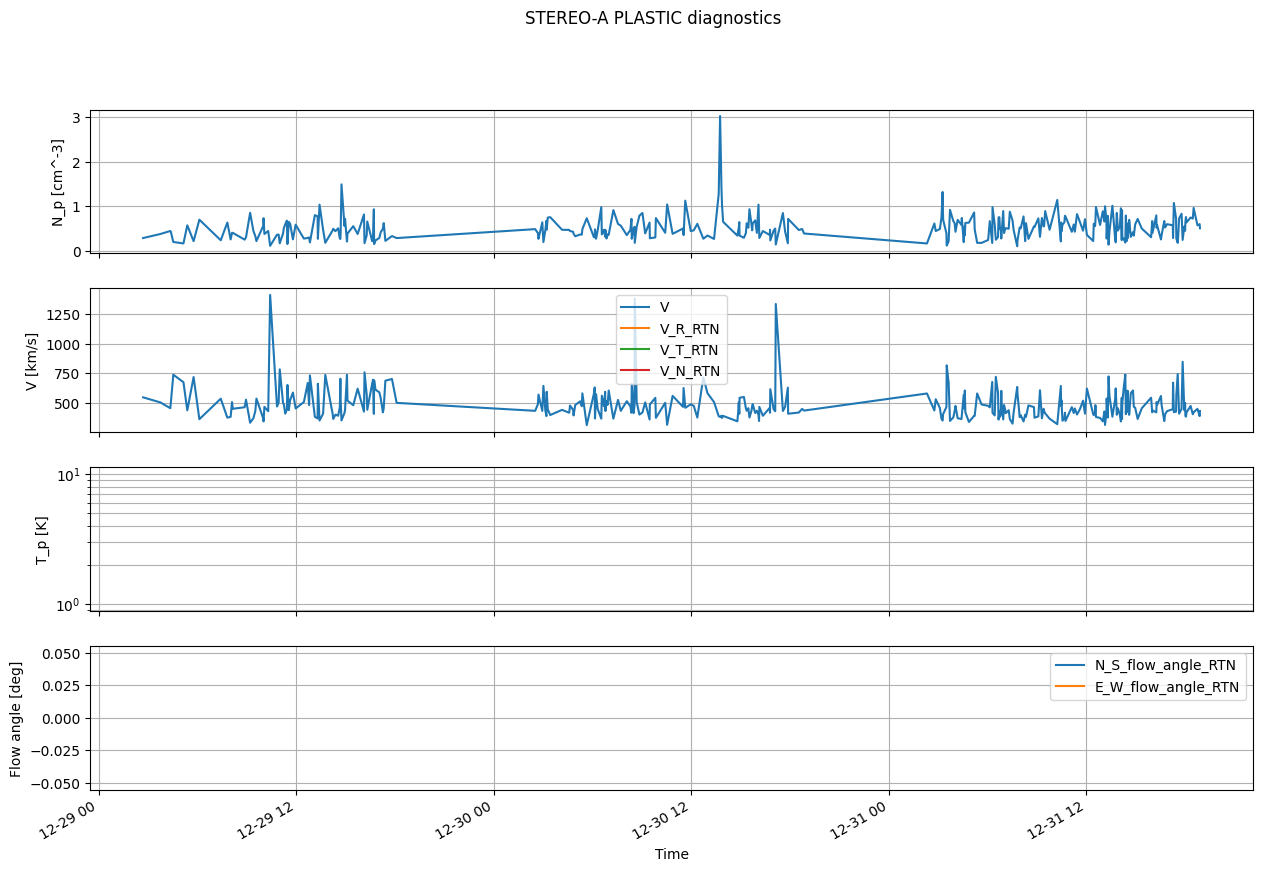

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
plt.subplots_adjust(hspace=0.25)

plastic["N_p"].plot(ax=axes[0], color="tab:blue")
axes[0].set_ylabel("N_p [cm^-3]")
axes[0].grid(True)

plastic[["V", "V_R_RTN", "V_T_RTN", "V_N_RTN"]].plot(ax=axes[1])
axes[1].set_ylabel("V [km/s]")
axes[1].grid(True)

plastic["T_p"].plot(ax=axes[2], color="tab:red", logy=True)
axes[2].set_ylabel("T_p [K]")
axes[2].grid(True, which="both")

plastic[["N_S_flow_angle_RTN", "E_W_flow_angle_RTN"]].plot(ax=axes[3])
axes[3].set_ylabel("Flow angle [deg]")
axes[3].set_xlabel("Time")
axes[3].grid(True)

fig.suptitle("STEREO-A PLASTIC diagnostics")
plt.show()

## STEREO-A Horizons Coordinates

In [14]:
HORIZONS_BODY = -234  # STEREO-A spacecraft
HORIZONS_STEP = "10m"
HORIZONS_MAX_ROWS_PER_QUERY = 45000

stereo_coords = horizons_coord_frame(
    HORIZONS_BODY,
    t_start,
    t_end,
    HORIZONS_STEP,
    max_rows=HORIZONS_MAX_ROWS_PER_QUERY,
)

stereo_coords

Fetching HORIZONS coordinates from 2025-12-29 00:00:00+00:00 to 2026-01-01 00:00:00+00:00
INFO: Obtained JPL HORIZONS location for STEREO-A (spacecraft) (-234)    [sunpy.coordinates.ephemeris]


,radialDistance,heliographicLatitude,heliographicLongitude
Epoch,,,
2025-12-29 00:00:00.000181+00:00,22654.578488,-7.017820,50.821735
2025-12-29 00:10:00.000145+00:00,22654.566664,-7.018093,50.821941
2025-12-29 00:20:00.000109+00:00,22654.554838,-7.018366,50.822148
2025-12-29 00:30:00.000154+00:00,22654.543010,-7.018638,50.822354
2025-12-29 00:40:00.000118+00:00,22654.531180,-7.018911,50.822561
...,...,...,...
2025-12-31 23:20:00.000079+00:00,22649.344350,-7.124370,50.910829
2025-12-31 23:30:00.000043+00:00,22649.331720,-7.124595,50.911039
2025-12-31 23:40:00.000088+00:00,22649.319088,-7.124820,50.911248


In [15]:
plastic_u = plastic.reset_index().sort_values("Epoch")
coords_u = stereo_coords.reset_index().sort_values("Epoch")
coord_tolerance = pd.Timedelta(HORIZONS_STEP) / 2 + pd.Timedelta(minutes=1)

plastic = pd.merge_asof(
    plastic_u,
    coords_u,
    on="Epoch",
    direction="nearest",
    tolerance=coord_tolerance,
).set_index("Epoch")

plastic

,N_p,V_R_RTN,V_T_RTN,V_N_RTN,V,V_X_HERTN,V_Y_HERTN,V_Z_HERTN,V_HERTN,N_S_flow_angle_RTN,E_W_flow_angle_RTN,T_p,P_inst,radialDistance,heliographicLatitude,heliographicLongitude
Epoch,,,,,,,,,,,,,,,,
2025-12-29 02:42:06.078000+00:00,0.286581,NaN,NaN,NaN,546.578625,NaN,NaN,NaN,546.578625,NaN,NaN,NaN,NaN,22654.389071,-7.022170,50.825041
2025-12-29 03:45:06.078000+00:00,0.377551,NaN,NaN,NaN,503.677197,NaN,NaN,NaN,503.677197,NaN,NaN,NaN,NaN,22654.306047,-7.024065,50.826489
2025-12-29 04:21:06.082000+00:00,0.444840,NaN,NaN,NaN,455.042642,NaN,NaN,NaN,455.042642,NaN,NaN,NaN,NaN,22654.270437,-7.024875,50.827109
2025-12-29 04:23:06.082000+00:00,0.429023,NaN,NaN,NaN,498.310929,NaN,NaN,NaN,498.310929,NaN,NaN,NaN,NaN,22654.270437,-7.024875,50.827109
2025-12-29 04:32:06.082000+00:00,0.197906,NaN,NaN,NaN,737.962916,NaN,NaN,NaN,737.962916,NaN,NaN,NaN,NaN,22654.258563,-7.025145,50.827316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 18:28:06.203000+00:00,0.723533,NaN,NaN,NaN,403.516999,NaN,NaN,NaN,403.516999,NaN,NaN,NaN,NaN,22649.709832,-7.117798,50.904754
2025-12-31 18:31:06.203000+00:00,0.963107,NaN,NaN,NaN,420.361028,NaN,NaN,NaN,420.361028,NaN,NaN,NaN,NaN,22649.709832,-7.117798,50.904754
2025-12-31 18:45:06.207000+00:00,0.571699,NaN,NaN,NaN,449.283824,NaN,NaN,NaN,449.283824,NaN,NaN,NaN,NaN,22649.684676,-7.118255,50.905172


## Export

In [16]:
plastic_export = plastic.loc[:, EXPORT_COLUMNS]
parquet_path = save_parquet(plastic_export, "STEREO-A PLASTIC", tShock)

if CLEAN_UP_CDFS:
    shutil.rmtree(cdf_dir, ignore_errors=True)

parquet_path

PosixPath('Data/Custom/2025-12-29 00-00-00-2026-01-01 00-00-00/STEREO-A PLASTIC.parquet')

In [17]:
!curl -d "ISWA downloader finished" ntfy.sh/helio-n

{"id":"5zmHhbnzC5PK","time":1782918811,"expires":1782962011,"event":"message","topic":"helio-n","message":"ISWA downloader finished"}
